In [45]:
import torch
import sklearn
import matplotlib.pyplot as plt

In [46]:
from sklearn.datasets import make_moons

n_samples = 1000

X, y = make_moons(n_samples,
                    noise=0.03,
                    random_state=42)

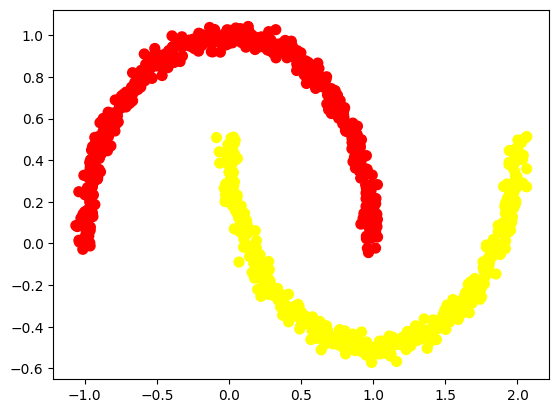

In [47]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

In [48]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [50]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [51]:
import torch.nn as nn

class MoonModelV1(torch.nn.Module):
    def __init__(self, input_dim):
      super().__init__()
      self.linear_stack_layers = torch.nn.Sequential(
          torch.nn.Linear(input_dim, 10),
          nn.ReLU(),
          torch.nn.Linear(10, 10),
          nn.ReLU(),
          torch.nn.Linear(10, 1),
        )

    def forward(self, x):
      return self.linear_stack_layers(x)

moon_1 = MoonModelV1(2).to(device)
moon_1

MoonModelV1(
  (linear_stack_layers): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [52]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(moon_1.parameters(),
                            lr=0.1)

In [53]:
!pip install torchmetrics
import torchmetrics

In [88]:
def accuracy_fn_torchmetrics(y_true, y_pred):
    """
    Calculates accuracy using torchmetrics between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels (0s, 1s, etc.).
        y_pred (torch.Tensor): Predictions (logits or class labels).

    Returns:
        float: Accuracy percentage.
    """
    # Move tensors to CPU for torchmetrics if they are on GPU
    y_true_cpu = y_true.cpu() if y_true.is_cuda else y_true
    y_pred_cpu = y_pred.cpu() if y_pred.is_cuda else y_pred

    # Initialize Accuracy metric for multiclass classification
    # Assuming K (number of classes) is available in the global scope
    accuracy_metric = torchmetrics.Accuracy(task='multiclass', num_classes=K).to(device) # Changed to multiclass

    # Compute accuracy. torchmetrics expects class labels for y_pred (which argmax provides)
    acc = accuracy_metric(y_pred_cpu, y_true_cpu.int()) # y_true should be int for torchmetrics
    return acc.item() * 100 # Return as percentage

In [55]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 500

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
  moon_1.train()

  y_logits = moon_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn_torchmetrics(y_true=y_train, y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  ### Testing
  moon_1.eval()
  with torch.inference_mode():
    test_logits = moon_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn_torchmetrics(y_true=y_test, y_pred=test_pred)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.6954, Acc: 37.75% | Test Loss: 0.6946, Test Acc: 49.50%
Epoch: 10 | Loss: 0.6820, Acc: 76.50% | Test Loss: 0.6821, Test Acc: 73.00%
Epoch: 20 | Loss: 0.6679, Acc: 79.75% | Test Loss: 0.6692, Test Acc: 77.00%
Epoch: 30 | Loss: 0.6507, Acc: 77.63% | Test Loss: 0.6531, Test Acc: 73.00%
Epoch: 40 | Loss: 0.6261, Acc: 76.13% | Test Loss: 0.6301, Test Acc: 69.00%
Epoch: 50 | Loss: 0.5933, Acc: 75.13% | Test Loss: 0.5996, Test Acc: 71.50%
Epoch: 60 | Loss: 0.5528, Acc: 76.13% | Test Loss: 0.5613, Test Acc: 72.50%
Epoch: 70 | Loss: 0.5071, Acc: 77.25% | Test Loss: 0.5180, Test Acc: 74.50%
Epoch: 80 | Loss: 0.4610, Acc: 78.62% | Test Loss: 0.4742, Test Acc: 74.50%
Epoch: 90 | Loss: 0.4200, Acc: 80.25% | Test Loss: 0.4349, Test Acc: 75.50%
Epoch: 100 | Loss: 0.3864, Acc: 81.88% | Test Loss: 0.4020, Test Acc: 77.00%
Epoch: 110 | Loss: 0.3593, Acc: 83.00% | Test Loss: 0.3746, Test Acc: 78.50%
Epoch: 120 | Loss: 0.3371, Acc: 84.13% | Test Loss: 0.3513, Test Acc: 80.00%
Epoch: 130

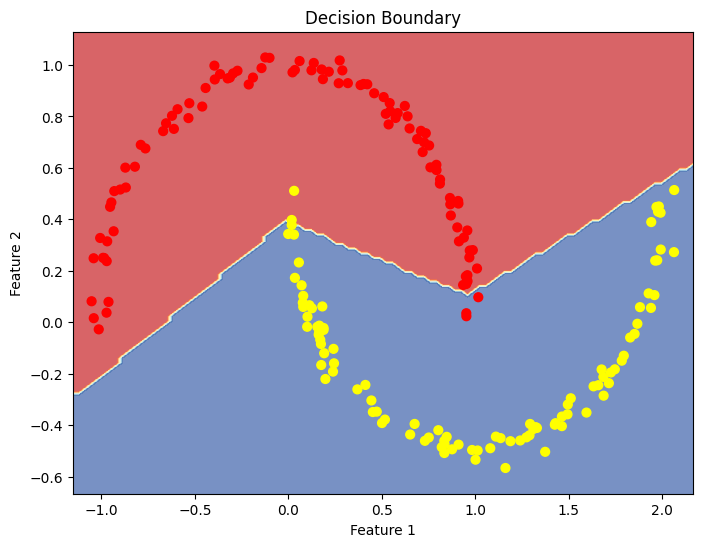

In [56]:
import numpy as np

# Visualize the decision boundary
def plot_decision_boundary(model, X, y):
    # Move model to CPU for plotting if it's on GPU
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_pred = torch.round(torch.sigmoid(model(torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).type(torch.float)))).squeeze()

    y_pred = y_pred.reshape(xx.shape).numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap="autumn")
    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

fig = plt.figure(figsize=(8, 6))
plot_decision_boundary(moon_1, X_test, y_test)

In [57]:
y_pred_probs = torch.sigmoid(y_logits) # Convert logits to prediction probabilities
y_pred_labels = torch.round(y_pred_probs) # Round probabilities to get binary labels (0 or 1)

# Display the first 5 prediction probabilities and labels
print("Prediction Probabilities (first 5):", y_pred_probs[:5])
print("Prediction Labels (first 5):", y_pred_labels[:5])

Prediction Probabilities (first 5): tensor([0.9586, 0.0450, 0.0119, 0.0150, 0.9796], device='cuda:0',
       grad_fn=<SliceBackward0>)
Prediction Labels (first 5): tensor([1., 0., 0., 0., 1.], device='cuda:0', grad_fn=<SliceBackward0>)


### Replicating the Tanh (hyperbolic tangent) activation function in pure PyTorch

The hyperbolic tangent (Tanh) activation function is a common choice in neural networks. It squashes input values to a range between -1 and 1, which can be beneficial for gradient flow and preventing vanishing/exploding gradients in certain network architectures. In PyTorch, you can easily apply the Tanh function using `torch.tanh()`.

In [58]:
def tanh_activation(x: torch.Tensor) -> torch.Tensor:
    """
    Replicates the Tanh (hyperbolic tangent) activation function using pure PyTorch.

    Args:
        x (torch.Tensor): The input tensor.

    Returns:
        torch.Tensor: The output tensor after applying the Tanh function.
    """
    return torch.tanh(x)

# Demonstrate the Tanh activation function
input_tensor = torch.randn(5) # Create a random input tensor
output_tensor = tanh_activation(input_tensor)

print(f"Input Tensor: {input_tensor}")
print(f"Output (Tanh activated) Tensor: {output_tensor}")

Input Tensor: tensor([ 0.3367,  0.1288,  0.2345,  0.2303, -1.1229])
Output (Tanh activated) Tensor: tensor([ 0.3245,  0.1281,  0.2303,  0.2263, -0.8086])


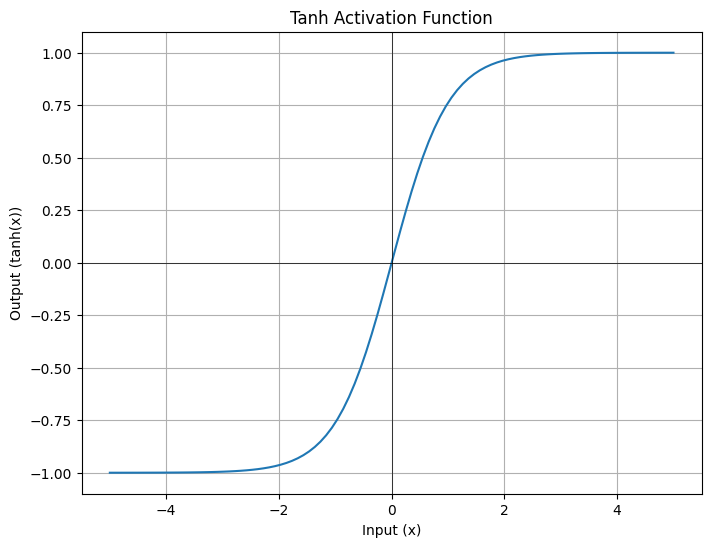

In [59]:
import numpy as np

# Generate a range of input values
x_values = torch.linspace(-5, 5, 100) # 100 points between -5 and 5

# Apply the tanh activation function
y_values = tanh_activation(x_values)

# Plot the Tanh function
plt.figure(figsize=(8, 6))
plt.plot(x_values.numpy(), y_values.numpy())
plt.title('Tanh Activation Function')
plt.xlabel('Input (x)')
plt.ylabel('Output (tanh(x))')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()

## Multiclass


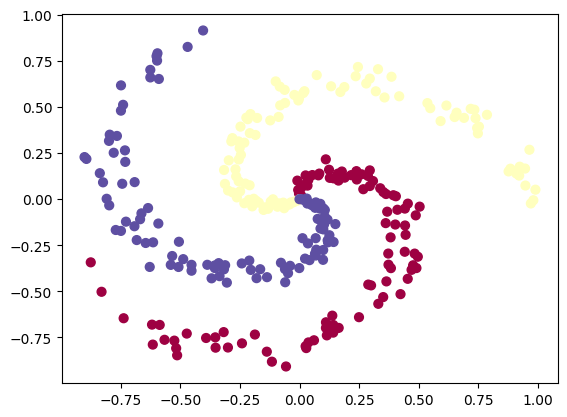

In [82]:
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j

X_spiral = torch.from_numpy(X).type(torch.float)
y_spiral = torch.from_numpy(y).type(torch.LongTensor)

X_spiral_train, X_spiral_test, y_spiral_train, y_spiral_test = train_test_split(X_spiral,
                                                    y_spiral,
                                                    test_size=0.2,
                                                    random_state=42)

# lets visualize the data:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)

(240, 60, 240, 60)

In [96]:
class SpiralModelV1(nn.Module):
  def __init__(self, input_features, output_features, hidden_units):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features),
        nn.ReLU()
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

spiral_1 = SpiralModelV1(input_features=2, output_features=3, hidden_units=10).to(device)
spiral_1

SpiralModelV1(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=3, bias=True)
    (3): ReLU()
  )
)

In [97]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(spiral_1.parameters(),
                            lr=0.03)

print(f"{loss_fn},{optimizer}")

CrossEntropyLoss(),Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.03
    maximize: False
    weight_decay: 0
)


In [99]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 500

X_spiral_train, y_spiral_train = X_spiral_train.to(device), y_spiral_train.to(device)
X_spiral_test, y_spiral_test = X_spiral_test.to(device), y_spiral_test.to(device)

for epoch in range(epochs):
  spiral_1.train()

  y_logits = spiral_1(X_spiral_train).squeeze()
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_spiral_train)
  acc = accuracy_fn_torchmetrics(y_true=y_spiral_train,
                                 y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  ### test
  spiral_1.eval()
  with torch.inference_mode():
    test_logits = spiral_1(X_spiral_test).squeeze()
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_spiral_test)
    test_acc = accuracy_fn_torchmetrics(y_true=y_spiral_test, y_pred=test_pred)

  if epochs % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.4734, Acc: 72.08% | Test Loss: 0.5426, Test Acc: 73.33%
Epoch: 1 | Loss: 0.4699, Acc: 72.50% | Test Loss: 0.5399, Test Acc: 73.33%
Epoch: 2 | Loss: 0.4662, Acc: 72.50% | Test Loss: 0.5368, Test Acc: 75.00%
Epoch: 3 | Loss: 0.4626, Acc: 72.50% | Test Loss: 0.5336, Test Acc: 73.33%
Epoch: 4 | Loss: 0.4592, Acc: 74.58% | Test Loss: 0.5301, Test Acc: 73.33%
Epoch: 5 | Loss: 0.4557, Acc: 75.42% | Test Loss: 0.5276, Test Acc: 75.00%
Epoch: 6 | Loss: 0.4523, Acc: 75.42% | Test Loss: 0.5257, Test Acc: 75.00%
Epoch: 7 | Loss: 0.4487, Acc: 75.83% | Test Loss: 0.5240, Test Acc: 73.33%
Epoch: 8 | Loss: 0.4458, Acc: 76.67% | Test Loss: 0.5221, Test Acc: 76.67%
Epoch: 9 | Loss: 0.4432, Acc: 77.08% | Test Loss: 0.5202, Test Acc: 76.67%
Epoch: 10 | Loss: 0.4406, Acc: 78.75% | Test Loss: 0.5186, Test Acc: 76.67%
Epoch: 11 | Loss: 0.4381, Acc: 79.58% | Test Loss: 0.5175, Test Acc: 76.67%
Epoch: 12 | Loss: 0.4355, Acc: 79.58% | Test Loss: 0.5161, Test Acc: 78.33%
Epoch: 13 | Loss: 0.43

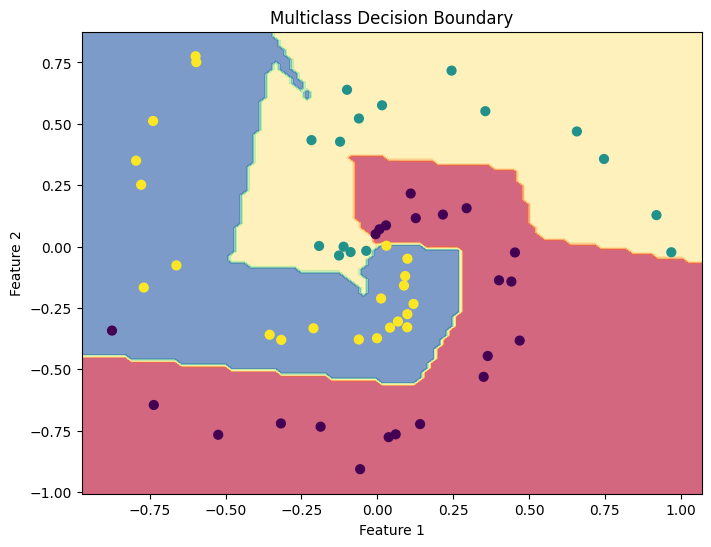

In [100]:
def plot_decision_boundary_multiclass(model, X, y):
    # Move model to CPU for plotting
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Make predictions across the grid
    model.eval()
    with torch.inference_mode():
        X_grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).type(torch.float)
        y_logits = model(X_grid)
        y_pred_labels = torch.softmax(y_logits, dim=1).argmax(dim=1)

    # Reshape predictions to match grid
    y_pred_labels = y_pred_labels.reshape(xx.shape).numpy()

    # Plot the decision boundary
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, y_pred_labels, cmap=plt.cm.Spectral, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40)
    plt.title("Multiclass Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# Plot the decision boundary for the spiral model
plot_decision_boundary_multiclass(spiral_1, X_spiral_test, y_spiral_test)